# $K_SKK$ veto efficiency
## Demonstrate and quantify the efficiency of the $K_S$ veto

### Add BESIII style

In [1]:
gInterpreter->AddIncludePath("/data/lhcb/users/tat/KKpipi_Analysis_BESIII/include");

In [2]:
gROOT->ProcessLine(".L /data/lhcb/users/tat/KKpipi_Analysis_BESIII/src/Bes3plotstyle.cpp");

In [3]:
SetStyle();
SetPrelimStyle();

### Turn off statistics box

In [4]:
gStyle->SetOptStat(0);

### Load the signal MC

In [5]:
TChain Chain("KKpipiSingleTag");
Chain.Add("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/Tuples/SignalMC/SingleTag/KSKK/*.root");

### Set up cuts for the veto

In [6]:
TCut TruthCut("IsSameDMother == 1");
TCut FSCut("KSFitSuccess == 0 || (KSFitSuccess == 1 && KSDecayLengthFit/KSDecayLengthErrorFit < 2)");
TCut MassCut("Mpipi< 0.477 || Mpipi > 0.507");
TCut Veto = FSCut && MassCut;

### Make plots

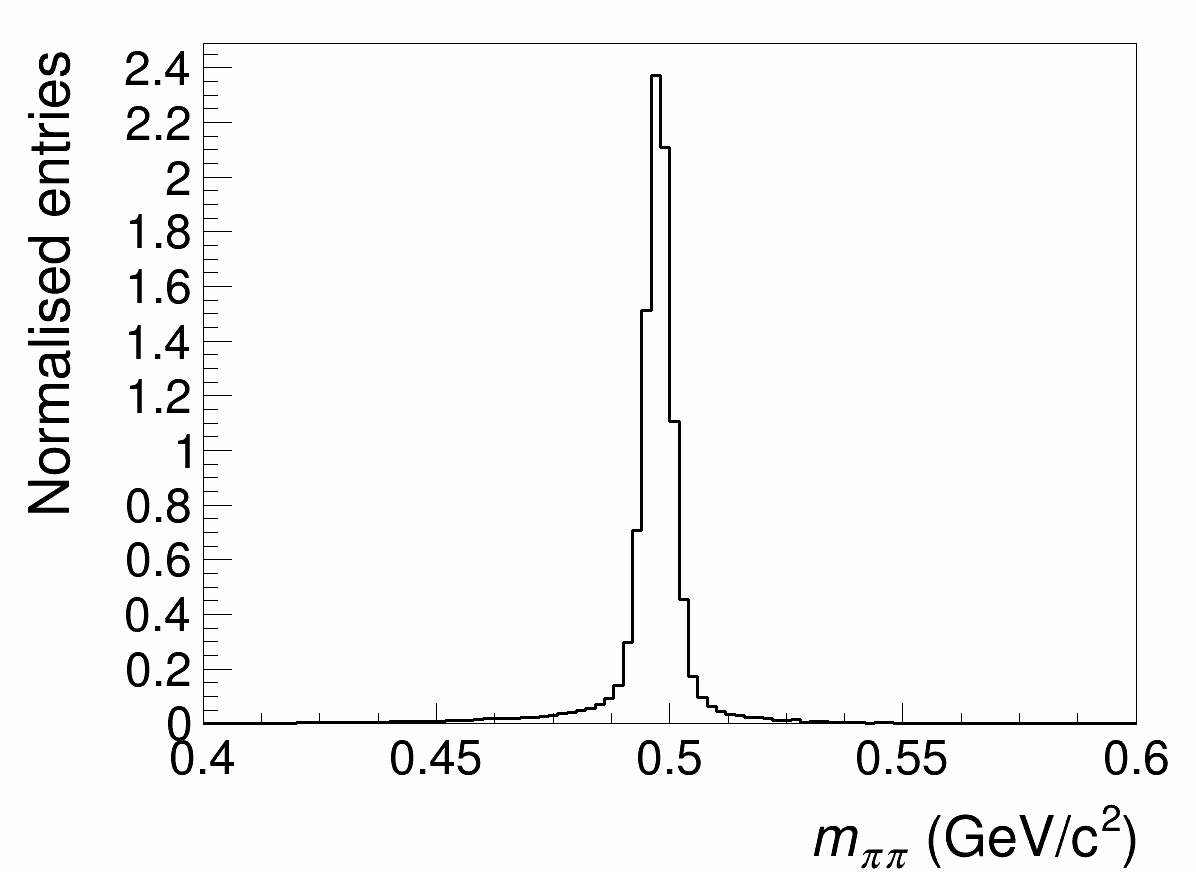

Info in <TCanvas::Print>: pdf file Mpipi_NoKSVeto.pdf has been created


In [7]:
TCanvas c1("c1", "", 1200, 900);
TH1D h1("h1", "", 100, 0.4, 0.6);
double NoVetoYield = Chain.Draw("Mpipi >> h1", TruthCut);
h1.Scale(10.0/h1.Integral());
h1.SetTitle(";#it{m_{#pi#pi}} (GeV/c^{2});Normalised entries");
h1.SetLineWidth(3);
h1.SetLineColor(kBlack);
h1.GetXaxis()->SetNdivisions(-404);
h1.Draw("HIST");
c1.Draw();
c1.SaveAs("Mpipi_NoKSVeto.pdf");

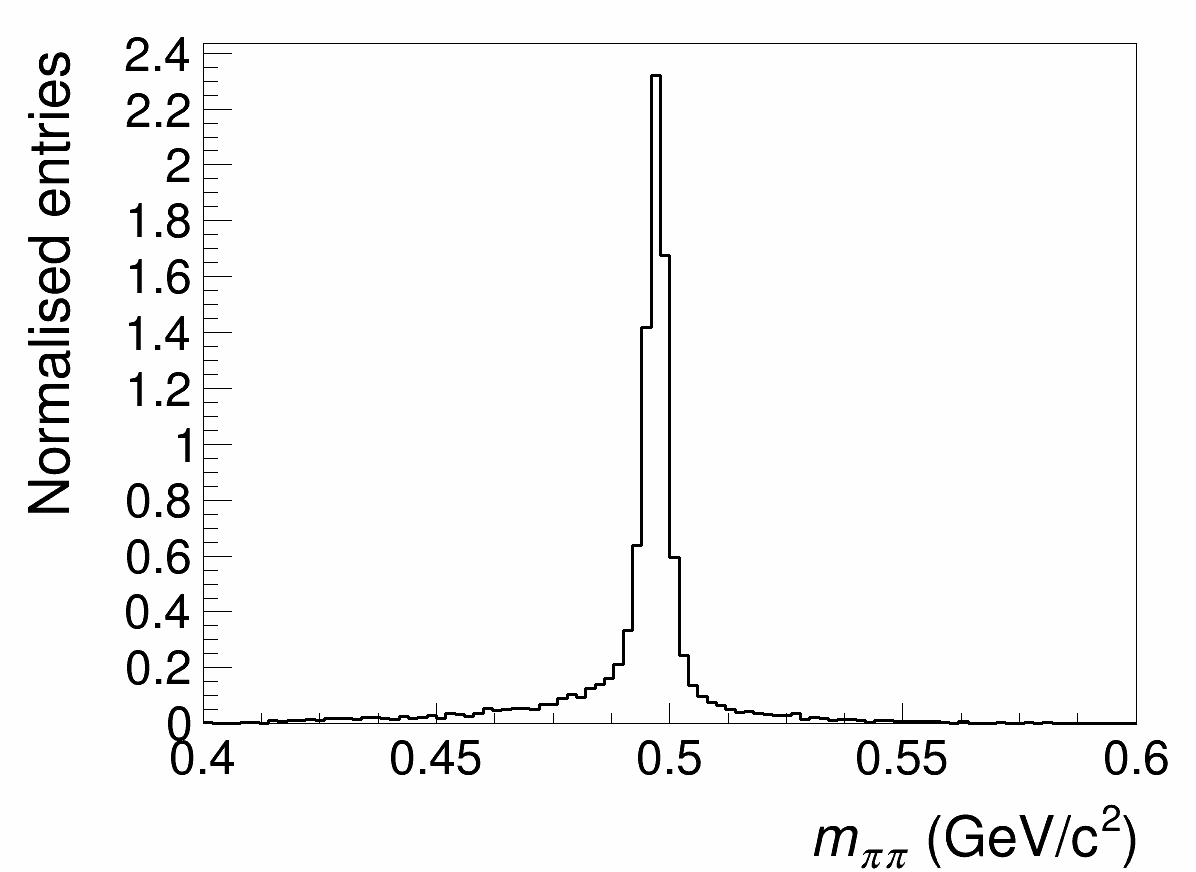

Info in <TCanvas::Print>: pdf file Mpipi_FSCut.pdf has been created


In [8]:
TCanvas c2("c2", "", 1200, 900);
TH1D h2("h2", "", 100, 0.4, 0.6);
double FSCutYield = Chain.Draw("Mpipi >> h2", TruthCut && FSCut);
h2.Scale(10.0/h2.Integral());
h2.SetTitle(";#it{m_{#pi#pi}} (GeV/c^{2});Normalised entries");
h2.SetLineWidth(3);
h2.SetLineColor(kBlack);
h2.GetXaxis()->SetNdivisions(-404);
h2.Draw("HIST");
c2.Draw();
c2.SaveAs("Mpipi_FSCut.pdf");

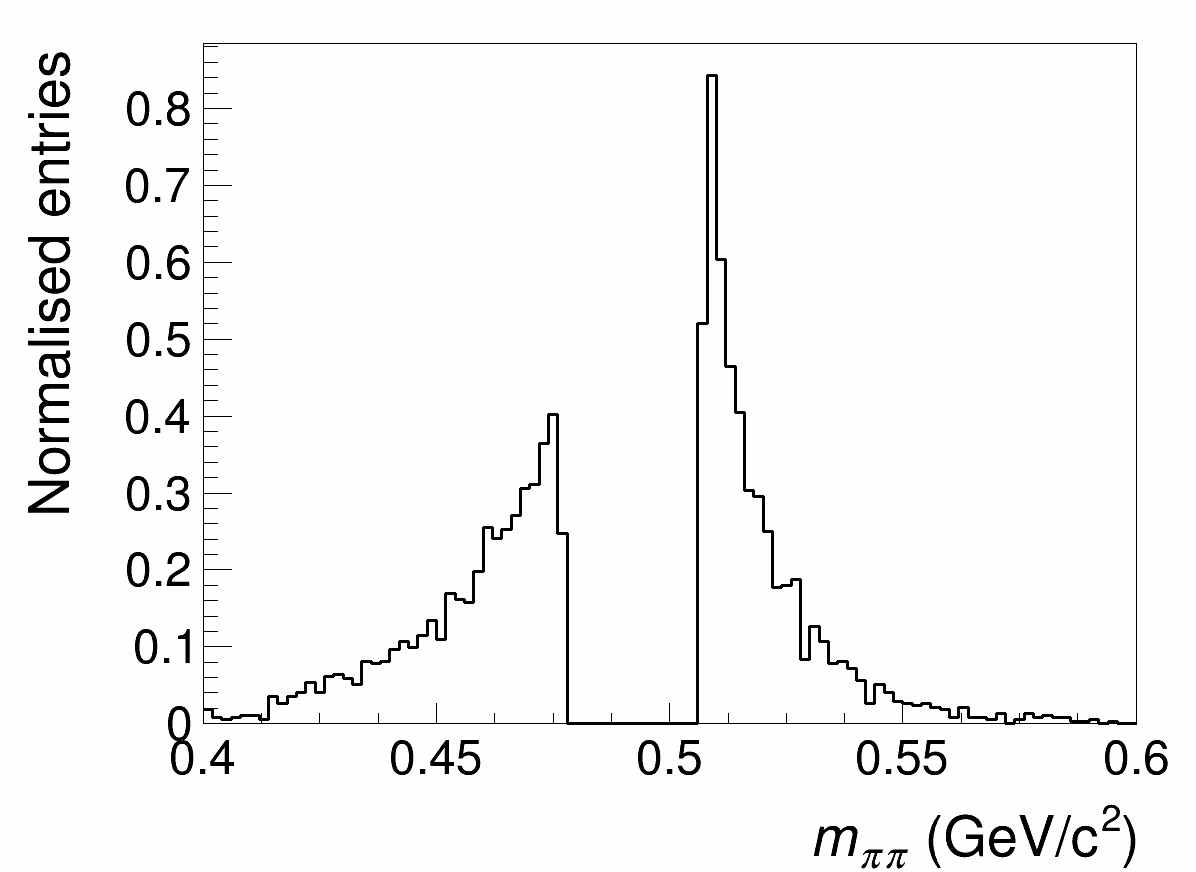

Info in <TCanvas::Print>: pdf file Mpipi_MassCut.pdf has been created


In [9]:
TCanvas c3("c3", "", 1200, 900);
TH1D h3("h3", "", 100, 0.4, 0.6);
double MassCutYield = Chain.Draw("Mpipi >> h3", TruthCut && MassCut);
h3.Scale(10.0/h3.Integral());
h3.SetTitle(";#it{m_{#pi#pi}} (GeV/c^{2});Normalised entries");
h3.SetLineWidth(3);
h3.SetLineColor(kBlack);
h3.GetXaxis()->SetNdivisions(-404);
h3.Draw("HIST");
c3.Draw();
c3.SaveAs("Mpipi_MassCut.pdf");

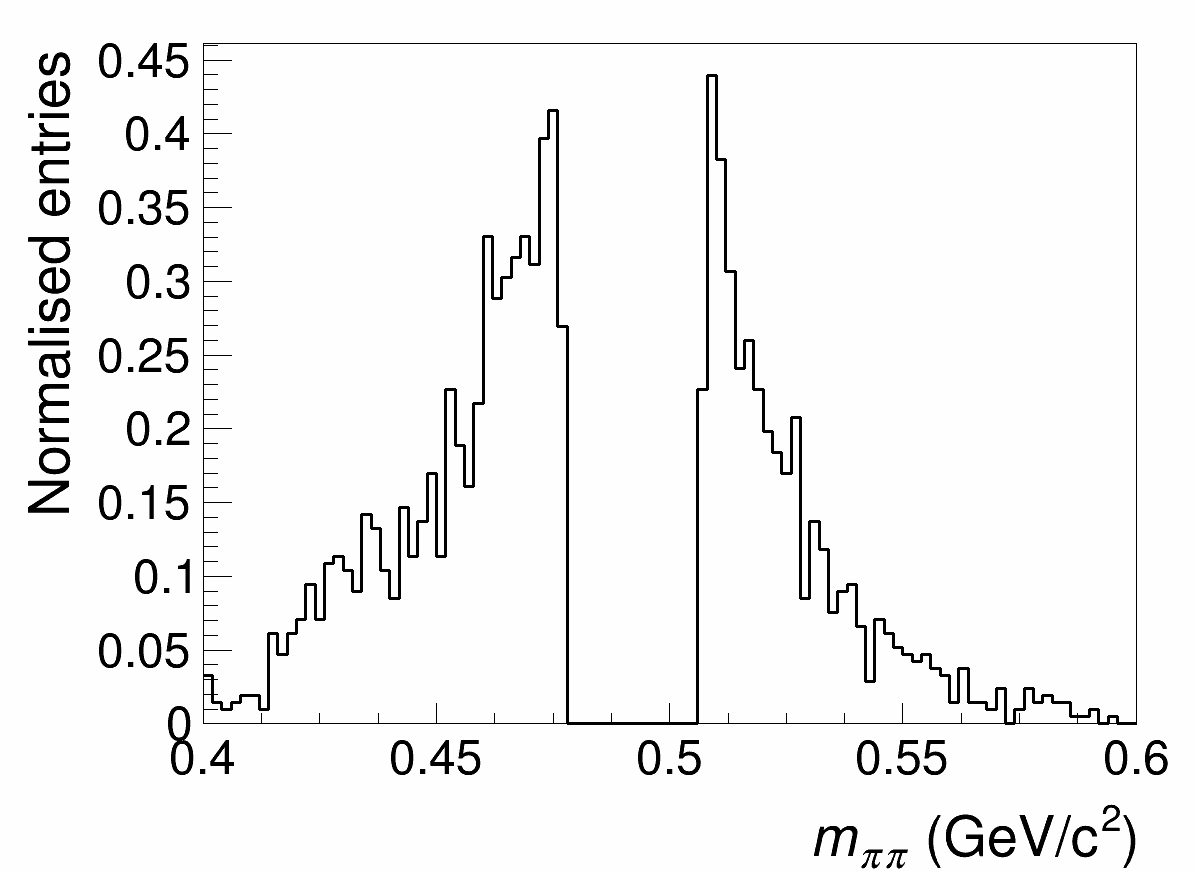

Info in <TCanvas::Print>: pdf file Mpipi_Veto.pdf has been created


In [10]:
TCanvas c4("c4", "", 1200, 900);
TH1D h4("h4", "", 100, 0.4, 0.6);
double VetoYield = Chain.Draw("Mpipi >> h4", TruthCut && Veto);
h4.Scale(10.0/h4.Integral());
h4.SetTitle(";#it{m_{#pi#pi}} (GeV/c^{2});Normalised entries");
h4.SetLineWidth(3);
h4.SetLineColor(kBlack);
h4.GetXaxis()->SetNdivisions(-404);
h4.Draw("HIST");
c4.Draw();
c4.SaveAs("Mpipi_Veto.pdf");

### Summarise in a table

In [11]:
int BlankSpaces = 8;
std::string Blank = BlankSpaces == 0 ? "" : std::string(BlankSpaces, ' ');
int Width = 25;
std::cout << Blank << "\\toprule" << "\n";
std::cout << Blank;
std::cout << std::left << std::setw(42) << "$\\kshort$ cut" << " & ";
std::cout << std::left << std::setw(Width) << "Efficiency ($10^{-2}$)" << " & ";
std::cout << std::left << std::setw(Width) << "MC yield" << " \\\\" << "\n";
std::cout << Blank << "\\midrule" << "\n";
std::cout << Blank;
std::cout << std::left << std::setw(42) << "No veto" << " & ";
std::cout << std::left << std::setw(Width);
std::stringstream ss;
ss << "$";
ss << std::fixed << std::setprecision(2);
ss << (1.0 - NoVetoYield/NoVetoYield)*100.0 << "$";
std::cout << ss.str() << " & ";
ss.str("");
std::cout << std::left << std::setw(Width) << NoVetoYield << " \\\\" << "\n";
std::cout << Blank;
std::cout << std::left << std::setw(42) << "Flight significance cut" << " & ";
std::cout << std::left << std::setw(Width);
ss << "$";
ss << std::fixed << std::setprecision(2);
ss << (1.0 - FSCutYield/NoVetoYield)*100.0 << "$";
std::cout << ss.str() << " & ";
ss.str("");
std::cout << std::left << std::setw(Width) << FSCutYield << " \\\\" << "\n";
std::cout << Blank;
std::cout << std::left << std::setw(42) << "Invariant mass cut" << " & ";
std::cout << std::left << std::setw(Width);
ss << "$";
ss << std::fixed << std::setprecision(2);
ss << (1.0 - MassCutYield/NoVetoYield)*100.0 << "$";
std::cout << ss.str() << " & ";
ss.str("");
std::cout << std::left << std::setw(Width) << MassCutYield << " \\\\" << "\n";
std::cout << Blank;
std::cout << std::left << std::setw(42) << "Flight significance and invariant mass cut" << " & ";
std::cout << std::left << std::setw(Width);
ss << "$";
ss << std::fixed << std::setprecision(2);
ss << (1.0 - VetoYield/NoVetoYield)*100.0 << "$";
std::cout << ss.str() << " & ";
std::cout << std::left << std::setw(Width) << VetoYield << " \\\\" << "\n";
std::cout << Blank << "\\bottomrule" << "\n";

        \toprule
        $\kshort$ cut                              & Efficiency ($10^{-2}$)    & MC yield                  \\
        \midrule
        No veto                                    & $0.00$                    & 49778                     \\
        Flight significance cut                    & $74.56$                   & 12665                     \\
        Invariant mass cut                         & $92.18$                   & 3893                      \\
        Flight significance and invariant mass cut & $95.42$                   & 2282                      \\
        \bottomrule
